In [1]:
# This code calculates the predicted association scores using collaborative filtering technique
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import accuracy_score
import scipy as sp
from tqdm import tqdm
import random

In [2]:
# random seeds for reproducibility
SEED = 1002
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# reading data sets associations, mirna names and disease names respectively
m_d_associations = pd.read_csv('datasets/1.miRNA_disease_association/miRNA-disease-association-data.csv', header=None, names=["MiRNA","Disease"])
disease_names = pd.read_csv('datasets/1.miRNA_disease_association/disease name.csv', header=None)
mirna_names = pd.read_csv('datasets/1.miRNA_disease_association/miRNA name.csv', header=None)

In [4]:
m_d_associations.shape, disease_names.shape, mirna_names.shape

((5431, 2), (383, 2), (495, 2))

In [ ]:
# importing adjacency matrix and integrated mirna and disease features

# A = Adjacency matrix, SM = integrated mirna features, SD = integrated disease features
nm = len(mirna_names)
nd = len(disease_names)
A = np.loadtxt("datasets/adjacency_matrix.txt")
SM = np.loadtxt("datasets/mirna_integrated_similarity.txt")
SD = np.loadtxt("datasets/disease_integrated_similarity.txt")

In [6]:
# creating dataframes from matrices
A_df = pd.DataFrame(A, index=range(1, nm+1), columns=range(1, nd+1))
SM_df = pd.DataFrame(SM, index=range(1, nm+1), columns=range(1, nm+1))
SD_df = pd.DataFrame(SD, index=range(1, nd+1), columns=range(1, nd+1))

In [7]:
A.shape, SM.shape, SD.shape

((495, 383), (495, 495), (383, 383))

In [8]:
A_df

,1,2,3,4,5,6,7,8,9,10,...,374,375,376,377,378,379,380,381,382,383
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


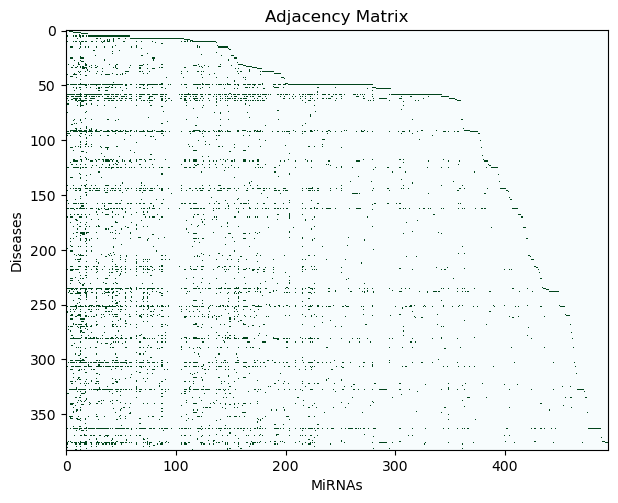

In [9]:
# adjacency matrix A
fig = plt.figure(figsize=(7, 10)) # in inches
plt.title('Adjacency Matrix')
plt.xlabel('MiRNAs')
plt.ylabel('Diseases')
plt.imshow(A_df.T, cmap="BuGn", interpolation="none")

In [10]:
SM_df

,1,2,3,4,5,6,7,8,9,10,...,486,487,488,489,490,491,492,493,494,495
1,1.000000,0.476800,0.093465,0.353500,0.544400,0.482700,0.490000,0.496600,0.476600,0.639200,...,0.093465,0.093465,0.093465,0.077888,0.077888,0.077888,0.077888,0.077888,0.077888,0.077888
2,0.476800,1.000000,0.077888,0.289800,0.402700,0.474700,0.524900,0.326500,0.487100,0.422700,...,0.064907,0.064907,0.064907,0.054089,0.054089,0.054089,0.064907,0.064907,0.064907,0.064907
3,0.093465,0.077888,1.000000,0.147435,0.008736,0.009570,0.015095,0.037562,0.012579,0.006067,...,0.161507,0.161507,0.161507,0.161507,0.193809,0.193809,0.161507,0.161507,0.161507,0.161507
4,0.353500,0.289800,0.147435,1.000000,0.420600,0.417500,0.309400,0.192000,0.221200,0.315800,...,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237
5,0.544400,0.402700,0.008736,0.420600,1.000000,0.805400,0.541500,0.438800,0.278600,0.445200,...,0.012579,0.012579,0.012579,0.010483,0.012579,0.012579,0.010483,0.010483,0.010483,0.010483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,0.077888,0.054089,0.193809,0.440237,0.012579,0.013780,0.015095,0.064907,0.018114,0.005055,...,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,0.833334,0.833334,0.833334,0.833334
492,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334
493,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334
494,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334


In [11]:
SD_df

,1,2,3,4,5,6,7,8,9,10,...,374,375,376,377,378,379,380,381,382,383
1,1.000000,0.038240,0.460301,0.530038,0.754171,0.036330,0.754171,0.013534,0.460301,0.460301,...,0.460301,0.493940,0.159791,0.059719,0.049938,0.702809,0.399739,0.868430,0.493940,0.568774
2,0.038240,1.000000,0.460301,0.530038,0.754171,0.031550,0.754171,0.084313,0.460301,0.460301,...,0.460301,0.493940,0.073187,0.097589,0.121246,0.702809,0.399739,0.754171,0.034299,0.568774
3,0.460301,0.460301,1.000000,0.015619,0.610340,0.152393,0.244850,0.010953,0.188205,0.164830,...,0.323504,0.347146,0.112303,0.066923,0.056765,0.493940,0.372515,0.530038,0.059536,0.610340
4,0.530038,0.530038,0.015619,1.000000,0.610340,0.033856,0.610340,0.010953,0.372515,0.372515,...,0.372515,0.399739,0.148909,0.002015,0.033856,0.568774,0.164015,0.610340,0.098012,0.460301
5,0.754171,0.754171,0.610340,0.610340,1.000000,0.041835,0.868430,0.015584,0.530038,0.530038,...,0.530038,0.568774,0.188323,0.001416,0.036330,0.809287,0.460301,0.868430,0.568774,0.092230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0.702809,0.702809,0.493940,0.568774,0.809287,0.033856,0.809287,0.019256,0.493940,0.493940,...,0.493940,0.530038,0.148909,0.001320,0.029402,1.000000,0.428953,0.809287,0.530038,0.610340
380,0.399739,0.399739,0.372515,0.164015,0.460301,0.038985,0.530038,0.012612,0.280940,0.280940,...,0.428953,0.301472,0.097527,0.002672,0.044892,0.428953,1.000000,0.460301,0.119578,0.460301
381,0.868430,0.754171,0.530038,0.610340,0.868430,0.041835,0.868430,0.015584,0.530038,0.530038,...,0.530038,0.568774,0.159791,0.001631,0.036330,0.809287,0.460301,1.000000,0.568774,0.654945
382,0.493940,0.034299,0.059536,0.098012,0.568774,0.090869,0.106929,0.010207,0.029568,0.026842,...,0.347146,0.372515,0.120510,0.028992,0.025345,0.530038,0.119578,0.568774,1.000000,0.493940


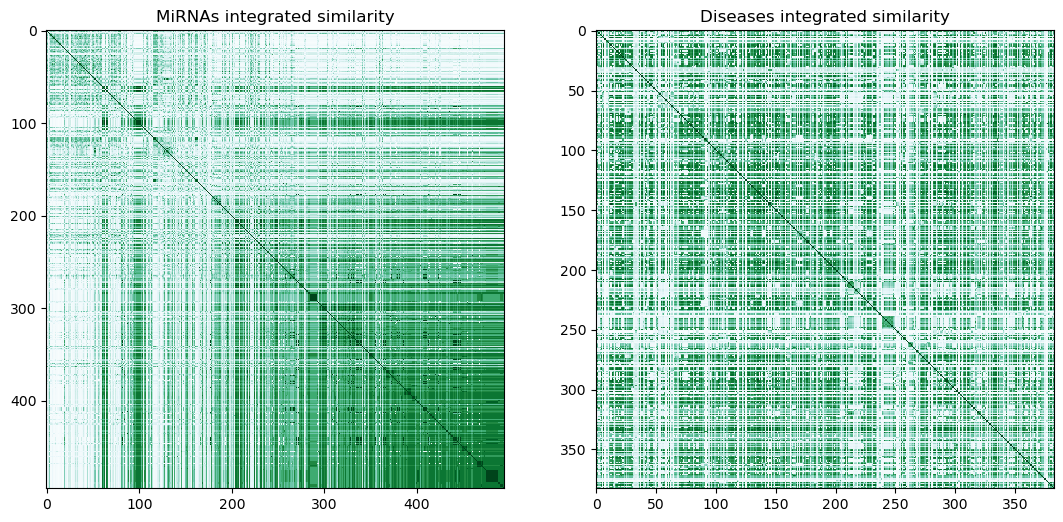

In [12]:
# integrated mirna and disease similarities

fig, (fig1, fig2) = plt.subplots(1, 2, figsize=(13,13))
fig1.title.set_text('MiRNAs integrated similarity')
fig2.title.set_text('Diseases integrated similarity')
fig1.imshow(SM, cmap="BuGn", interpolation="none")
fig2.imshow(SD, cmap="BuGn", interpolation="none")

# Generating features and training the model

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import random
from sklearn.decomposition import TruncatedSVD

In [14]:
# calculating cosine similarities for collaborative filtering
mirna_similarity_cosine = cosine_similarity(SM)
disease_similarity_cosine = cosine_similarity(SD)

In [15]:
type(mirna_similarity_cosine), type(disease_similarity_cosine)

(numpy.ndarray, numpy.ndarray)

In [16]:
# mirna similarity matrix using cosine similarity
print(mirna_similarity_cosine)
np.savetxt("datasets/mirna_similarity_cosine_matrix.txt", mirna_similarity_cosine)

[[1.         0.93806281 0.49286203 ... 0.40172316 0.40172316 0.4024244 ]
 [0.93806281 1.         0.48348297 ... 0.38458609 0.38458609 0.38549736]
 [0.49286203 0.48348297 1.         ... 0.92591413 0.92591413 0.92743335]
 ...
 [0.40172316 0.38458609 0.92591413 ... 1.         1.         0.99873738]
 [0.40172316 0.38458609 0.92591413 ... 1.         1.         0.99873738]
 [0.4024244  0.38549736 0.92743335 ... 0.99873738 0.99873738 1.        ]]


In [17]:
# diseases similarity matrix using cosine similarity
print(disease_similarity_cosine)
np.savetxt("datasets/disease_similarity_cosine_matrix.txt", disease_similarity_cosine)

[[1.         0.91976595 0.79240978 ... 0.92777234 0.79957548 0.95039413]
 [0.91976595 1.         0.77912727 ... 0.88035735 0.74311498 0.89977992]
 [0.79240978 0.77912727 1.         ... 0.79975302 0.779439   0.82489632]
 ...
 [0.92777234 0.88035735 0.79975302 ... 1.         0.80414326 0.95386929]
 [0.79957548 0.74311498 0.779439   ... 0.80414326 1.         0.79288968]
 [0.95039413 0.89977992 0.82489632 ... 0.95386929 0.79288968 1.        ]]


In [ ]:
#getting most similar items using cosine similarity

N_VALUES = list(range(5, 101, 5))
SIMILARITY_THRESHOLD = 0.05

def cosineSimilarity(cos_sim_matrix, n):
    similar_items = []
    for current_item in cos_sim_matrix.index:
        # excluding the current item without modifying original matrix
        candidates = cos_sim_matrix.drop(index=current_item)
        similar_i = (
            candidates[candidates[current_item] > SIMILARITY_THRESHOLD][current_item]
            .sort_values(ascending=False)
            .head(n)
        )
        similar_items.append(similar_i)
    return similar_items

In [19]:
#most similar miRNAs and diseases used for candidate generation

CANDIDATE_N = 5
similar_mirnas = cosineSimilarity(
    pd.DataFrame(mirna_similarity_cosine, index=range(1, nm+1), columns=range(1, nm+1)), 
    CANDIDATE_N
)
similar_diseases = cosineSimilarity(
    pd.DataFrame(disease_similarity_cosine, index=range(1, nd+1), columns=range(1, nd+1)),
    CANDIDATE_N
)

In [20]:
display(similar_mirnas), display(similar_diseases)

[24     0.956219
 52     0.954767
 42     0.954718
 138    0.950106
 59     0.948902
 Name: 1, dtype: float64,
 42     0.966577
 81     0.955004
 15     0.949304
 121    0.946010
 119    0.945959
 Name: 2, dtype: float64,
 87     0.948000
 247    0.942264
 241    0.941169
 203    0.941094
 213    0.940474
 Name: 3, dtype: float64,
 57     0.943947
 111    0.939570
 310    0.936957
 373    0.936450
 421    0.935226
 Name: 4, dtype: float64,
 6      0.982943
 75     0.972148
 28     0.963437
 120    0.963058
 148    0.956352
 Name: 5, dtype: float64,
 5      0.982943
 28     0.972155
 75     0.965807
 14     0.964887
 162    0.962443
 Name: 6, dtype: float64,
 117    0.989531
 59     0.986747
 119    0.986321
 118    0.980544
 162    0.979262
 Name: 7, dtype: float64,
 38     0.977068
 37     0.974039
 48     0.961876
 146    0.956681
 172    0.955486
 Name: 8, dtype: float64,
 10     0.984819
 24     0.959032
 138    0.951242
 38     0.947768
 47     0.947339
 Name: 9, dtype: float64,
 

[324    0.995198
 203    0.987158
 148    0.986928
 337    0.984453
 204    0.980406
 Name: 1, dtype: float64,
 177    0.997688
 178    0.994999
 149    0.952358
 81     0.948217
 151    0.937517
 Name: 2, dtype: float64,
 326    0.984122
 316    0.983486
 317    0.977887
 49     0.962290
 74     0.954944
 Name: 3, dtype: float64,
 20     0.993980
 75     0.977666
 306    0.964057
 194    0.963502
 160    0.958608
 Name: 4, dtype: float64,
 234    0.987762
 334    0.985292
 335    0.984653
 52     0.984486
 311    0.982067
 Name: 5, dtype: float64,
 53     0.962655
 65     0.929893
 54     0.879452
 285    0.869373
 210    0.777548
 Name: 6, dtype: float64,
 284    0.995636
 78     0.993194
 283    0.991943
 297    0.991691
 57     0.991071
 Name: 7, dtype: float64,
 169    0.487721
 171    0.392949
 349    0.315900
 173    0.289724
 373    0.284199
 Name: 8, dtype: float64,
 10     0.997487
 295    0.957159
 165    0.956846
 78     0.955328
 57     0.954915
 Name: 9, dtype: float64,
 

(None, None)

In [21]:
# analysis: getting index of similar items for mirna 1, and the length of similar mirnas
similar_mirnas[0].index, len(similar_mirnas)

(Index([24, 52, 42, 138, 59], dtype='int64'), 495)

In [ ]:
# Percentage of highest similarity values retained for CF calculation

# computing association scores on the respective quantiles 
KEEP_RATIOS = [0.60, 0.70, 0.80, 0.90]

class Association_prediction:
    def __init__(self, SMdf, SDdf, Adj):
        self.SMdf = SMdf
        self.SDdf = SDdf
        self.A = Adj.to_numpy()

        print("Computing miRNA and disease neigbbourhood")
        self.u_neighbor_cache = self.precompute_neighbors(SMdf)
        self.p_neighbor_cache = self.precompute_neighbors(SDdf)
        print("Neighborhood precomputation completed.")

    def precompute_neighbors(self, df):
        cache = {}
        for entity in df.index:
            similarities = df.loc[entity].drop(index=entity) #removing self
            similarities = similarities[similarities > SIMILARITY_THRESHOLD] #original minimum similarity threshold
            for keep_ratio in KEEP_RATIOS:
                if len(similarities) == 0:
                    cache[(entity, keep_ratio)] = (np.array([], dtype=int), np.array([], dtype=float))
                    continue

                #determining the neighborhood ratio
                # (e.g., keep_ratio=0.90 means 10th percentile cutoff to retain top 90%)
                cutoff_quantile = 1.0 - keep_ratio
                cutoff = similarities.quantile(cutoff_quantile)
                neighbors = (similarities[similarities >= cutoff].sort_values(ascending=False))
                cache[(entity, keep_ratio)] = (neighbors.index.to_numpy(dtype=int), neighbors.to_numpy(dtype=float))

        return cache

    def calculate_quantile_n_scores(self, u, p):
        scores = {}
        for keep_ratio in KEEP_RATIOS:
            #retrieving precomputed neighborhoods
            u_ids, u_sim = self.u_neighbor_cache[(u, keep_ratio)]
            p_ids, p_sim = self.p_neighbor_cache[(p, keep_ratio)]
            if len(u_ids) == 0 or len(p_ids) == 0:
                for n in N_VALUES:
                    scores[f"Score_top{int(keep_ratio * 100)}_n{n}"] = 0.0
                continue

            #extracting the adjacency block
            A_block = self.A[np.ix_(u_ids - 1, p_ids - 1)]

            #CF equation
            weighted = (u_sim[:, None] * p_sim[None, :] * A_block)
            cumulative = weighted.cumsum(axis=0).cumsum(axis=1)

            for n in N_VALUES:
                nu = min(n, len(u_ids))
                np_ = min(n, len(p_ids))
                if nu == 0 or np_ == 0:
                    score = 0.0
                else:
                    score = cumulative[nu - 1, np_ - 1]

                scores[f"Score_top{int(keep_ratio * 100)}_n{n}"] = float(score)

        return scores

    def calcScore(self, random_m, random_d):
        random_m_similar_mirnas = similar_mirnas[random_m]
        random_d_similar_diseases = similar_diseases[random_d]
        if (len(random_m_similar_mirnas) == 0 or len(random_d_similar_diseases) == 0):
            return None

        #original candidate-generation step
        random_u = random.choice(list(random_m_similar_mirnas.index))
        random_p = random.choice(list(random_d_similar_diseases.index))
        result = {"MiRNA": random_u, "Disease": random_p}
        result.update(
            self.calculate_quantile_n_scores(random_u, random_p)
        )

        return result

    def score_predictions(self):
        new_associations = []
        seen_pairs = set()
        for x in tqdm(range(nm)):
            for y in range(nd):
                prediction = self.calcScore(x, y)
                if prediction is None:
                    continue

                pair = (prediction["MiRNA"], prediction["Disease"])
                if pair in seen_pairs:
                    continue

                seen_pairs.add(pair)
                new_associations.append(prediction)

        print("Execution has completed!")

        return new_associations

In [23]:
# class object
pred = Association_prediction(SM_df, SD_df, A_df)
predicted_scores = pred.score_predictions()
predicted_scores

Computing miRNA and disease neigbbourhood
Neighborhood precomputation completed.


100%|██████████| 495/495 [14:40<00:00,  1.78s/it]


Execution has completed!


[{'MiRNA': 59,
  'Disease': 204,
  'Score_top50_n5': 0.0,
  'Score_top50_n10': 0.39910156952029113,
  'Score_top50_n15': 0.39910156952029113,
  'Score_top50_n20': 1.1188759707059148,
  'Score_top50_n25': 3.579598687629142,
  'Score_top50_n30': 3.9280420062392265,
  'Score_top50_n35': 4.327143575759518,
  'Score_top50_n40': 5.341895478931923,
  'Score_top50_n45': 7.306031831391396,
  'Score_top50_n50': 8.663462120150228,
  'Score_top50_n55': 9.991074498221089,
  'Score_top50_n60': 11.777540768271388,
  'Score_top50_n65': 12.804682581003759,
  'Score_top50_n70': 13.79154192915693,
  'Score_top50_n75': 14.716268627398547,
  'Score_top50_n80': 15.632572628500876,
  'Score_top50_n85': 16.61100927951476,
  'Score_top50_n90': 17.605742018472046,
  'Score_top50_n95': 19.693209466086696,
  'Score_top50_n100': 21.904737557067588,
  'Score_top60_n5': 0.0,
  'Score_top60_n10': 0.0,
  'Score_top60_n15': 0.0,
  'Score_top60_n20': 1.286658539082009,
  'Score_top60_n25': 3.051776333567133,
  'Score_to

In [24]:
# predicted_scores_df = pd.DataFrame(predicted_scores)
# display(predicted_scores_df.head())
# print(predicted_scores_df.shape)

# predicted_scores_df.to_csv("datasets/predicted_associations/new_scores/predicted_multi_n_scores_new4_Thr_0p05_Q70finer.csv", index=False)

In [ ]:
predicted_scores_df = pd.DataFrame(predicted_scores)
display(predicted_scores_df.head())
print(predicted_scores_df.shape)

for q in [60, 70, 80, 90]:
    q_cols = [
        c for c in predicted_scores_df.columns
        if c.startswith(f"Score_top{q}_")
    ]

    q_df = predicted_scores_df[["MiRNA", "Disease"] + q_cols]
    q_df.to_csv(f"datasets/predicted_associations/new_scores2/predicted_multi_n_scores_new4_Thr_0p05_Q{q}_finer.csv", index=False)
    print(f"Q{q}: {q_df.shape}")

,MiRNA,Disease,Score_top50_n5,Score_top50_n10,Score_top50_n15,Score_top50_n20,Score_top50_n25,Score_top50_n30,Score_top50_n35,Score_top50_n40,...,Score_top90_n55,Score_top90_n60,Score_top90_n65,Score_top90_n70,Score_top90_n75,Score_top90_n80,Score_top90_n85,Score_top90_n90,Score_top90_n95,Score_top90_n100
0,59,204,0.00000,0.399102,0.399102,1.118876,3.579599,3.928042,4.327144,5.341895,...,9.528498,10.774446,13.079153,14.123201,14.884784,15.500556,16.527637,17.448640,19.460059,22.386318
1,138,178,0.00000,0.000000,0.438589,0.851841,1.598936,1.971862,2.338434,4.379145,...,12.996318,13.341474,14.322778,15.951008,16.915872,18.802879,19.868933,21.757728,24.323762,27.418207
2,52,316,0.00000,0.000000,0.000000,0.000000,1.664346,2.877946,3.472046,5.076549,...,8.707620,11.085643,11.533016,18.251616,19.956494,22.055767,29.186827,31.130276,35.939586,42.374705
3,42,194,0.52844,1.056879,1.056879,1.056879,1.606769,2.041071,2.464692,4.944233,...,6.815787,7.635932,8.460941,9.930064,11.531102,12.289253,18.404700,22.420523,25.017313,28.654087
4,52,311,0.00000,0.573137,0.573137,1.174679,1.776222,2.265112,2.818098,3.291854,...,6.361559,7.603733,8.400394,14.207641,15.419548,16.639628,20.855283,21.639805,24.109270,25.792667


(77093, 102)
Q50: (77093, 22)
Q60: (77093, 22)
Q70: (77093, 22)
Q80: (77093, 22)
Q90: (77093, 22)


In [26]:
predicted_scores_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
77088    False
77089    False
77090    False
77091    False
77092    False
Length: 77093, dtype: bool

In [27]:
scores = predicted_scores_df.drop_duplicates(keep="first")

In [28]:
scores

,MiRNA,Disease,Score_top50_n5,Score_top50_n10,Score_top50_n15,Score_top50_n20,Score_top50_n25,Score_top50_n30,Score_top50_n35,Score_top50_n40,...,Score_top90_n55,Score_top90_n60,Score_top90_n65,Score_top90_n70,Score_top90_n75,Score_top90_n80,Score_top90_n85,Score_top90_n90,Score_top90_n95,Score_top90_n100
0,59,204,0.00000,0.399102,0.399102,1.118876,3.579599,3.928042,4.327144,5.341895,...,9.528498,10.774446,13.079153,14.123201,14.884784,15.500556,16.527637,17.448640,19.460059,22.386318
1,138,178,0.00000,0.000000,0.438589,0.851841,1.598936,1.971862,2.338434,4.379145,...,12.996318,13.341474,14.322778,15.951008,16.915872,18.802879,19.868933,21.757728,24.323762,27.418207
2,52,316,0.00000,0.000000,0.000000,0.000000,1.664346,2.877946,3.472046,5.076549,...,8.707620,11.085643,11.533016,18.251616,19.956494,22.055767,29.186827,31.130276,35.939586,42.374705
3,42,194,0.52844,1.056879,1.056879,1.056879,1.606769,2.041071,2.464692,4.944233,...,6.815787,7.635932,8.460941,9.930064,11.531102,12.289253,18.404700,22.420523,25.017313,28.654087
4,52,311,0.00000,0.573137,0.573137,1.174679,1.776222,2.265112,2.818098,3.291854,...,6.361559,7.603733,8.400394,14.207641,15.419548,16.639628,20.855283,21.639805,24.109270,25.792667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77088,493,67,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.545788,0.545788
77089,493,354,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.723693,0.723693,0.723693,0.723693
77090,435,185,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
77091,404,172,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.674406,0.674406


In [29]:
predicted_scores_df.duplicated().sum()

np.int64(0)

In [30]:
# predicted_scores_df.Score.nunique()

In [31]:
# predicted_scores_df['Score_n30'].value_counts()

In [ ]:
#getting index of similar items for mirna 1, and the length of similar mirnas
similar_mirnas[0].index, len(similar_mirnas)

(Index([24, 52, 42, 138, 59], dtype='int64'), 495)

In [ ]:
#summary checks

keepr = int(KEEP_RATIOS[0] * 100)
score_cols = [f"Score_top{keepr}_n{n}" for n in N_VALUES]
summary = pd.DataFrame({
    "n": N_VALUES,
    "min": [predicted_scores_df[c].min() for c in score_cols],
    "mean": [predicted_scores_df[c].mean() for c in score_cols],
    "median": [predicted_scores_df[c].median() for c in score_cols],
    "max": [predicted_scores_df[c].max() for c in score_cols],
    "nonzero": [(predicted_scores_df[c] > 0).sum() for c in score_cols],
    "zero": [(predicted_scores_df[c] == 0).sum() for c in score_cols],
})

summary["nonzero_pct"] = 100 * summary["nonzero"] / len(predicted_scores_df)
display(summary)

,n,min,mean,median,max,nonzero,zero,nonzero_pct
0,5,0.0,0.142391,0.000000,16.598237,8094,68999,10.499008
1,10,0.0,0.423395,0.000000,31.348758,14684,62409,19.047125
2,15,0.0,0.769708,0.000000,35.991870,21313,55780,27.645830
3,20,0.0,1.199678,0.000000,41.397708,26254,50839,34.054973
4,25,0.0,1.632946,0.000000,55.323353,29871,47222,38.746709
5,30,0.0,2.145769,0.000000,63.170356,32726,44367,42.450028
6,35,0.0,2.644623,0.000000,70.623845,34294,42799,44.483935
7,40,0.0,3.198160,0.000000,77.167423,35752,41341,46.375157
8,45,0.0,3.792201,0.000000,84.867170,37225,39868,48.285837
9,50,0.0,4.361605,0.502565,90.982037,41890,35203,54.336970


In [34]:
# checking for duplicates and missing values
print("Duplicate pairs:", predicted_scores_df.duplicated(["MiRNA", "Disease"]).sum())
print("Missing values:", predicted_scores_df[score_cols].isna().sum().sum())

# ensuring that scores should not decrease as n increases
scores = predicted_scores_df[score_cols].to_numpy()
decreasing = (np.diff(scores, axis=1) < -1e-12).any(axis=1)
print("Rows with decreasing scores:", decreasing.sum())

# checking num. of candidates with every CF feature equal to zero
all_zero = (scores == 0).all(axis=1)

print("All-zero candidates:", all_zero.sum())
print(f"All-zero percentage: {100 * all_zero.mean():.2f}%")

Duplicate pairs: 0
Missing values: 0
Rows with decreasing scores: 0
All-zero candidates: 8416
All-zero percentage: 10.92%


In [35]:
# non-zero CF scores at each neighborhood size

for col in score_cols:
    n = int(col.split("n")[-1])

    nonzero = predicted_scores_df[col].gt(0)

    print(
        f"n={n}: "
        f"nonzero candidates = {nonzero.sum()}, "
        f"nonzero percentage = {100 * nonzero.mean():.2f}%"
    )

n=5: nonzero candidates = 8094, nonzero percentage = 10.50%
n=10: nonzero candidates = 14684, nonzero percentage = 19.05%
n=15: nonzero candidates = 21313, nonzero percentage = 27.65%
n=20: nonzero candidates = 26254, nonzero percentage = 34.05%
n=25: nonzero candidates = 29871, nonzero percentage = 38.75%
n=30: nonzero candidates = 32726, nonzero percentage = 42.45%
n=35: nonzero candidates = 34294, nonzero percentage = 44.48%
n=40: nonzero candidates = 35752, nonzero percentage = 46.38%
n=45: nonzero candidates = 37225, nonzero percentage = 48.29%
n=50: nonzero candidates = 41890, nonzero percentage = 54.34%
n=55: nonzero candidates = 45030, nonzero percentage = 58.41%
n=60: nonzero candidates = 46549, nonzero percentage = 60.38%
n=65: nonzero candidates = 48577, nonzero percentage = 63.01%
n=70: nonzero candidates = 50875, nonzero percentage = 65.99%
n=75: nonzero candidates = 54543, nonzero percentage = 70.75%
n=80: nonzero candidates = 56898, nonzero percentage = 73.80%
n=85: nonz